## Amortization application.
#### **Retrieving data by yahoo finance**

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yfi
%matplotlib inline

In [24]:
gdr = yfi.download("GLD", start="2020-01-01", end="2026-02-27", progress=False)
gdr = round(gdr, 2)
gdr.tail()

## We want to plot the data.
with plt.style.context('ggplot'):
    plt.plot(gdr.Close)

gdr.index = pd.DatetimeIndex(gdr.index)
monthly = gdr.resample('BME').last()
monthly.tail()
plt.plot(monthly['Close'])

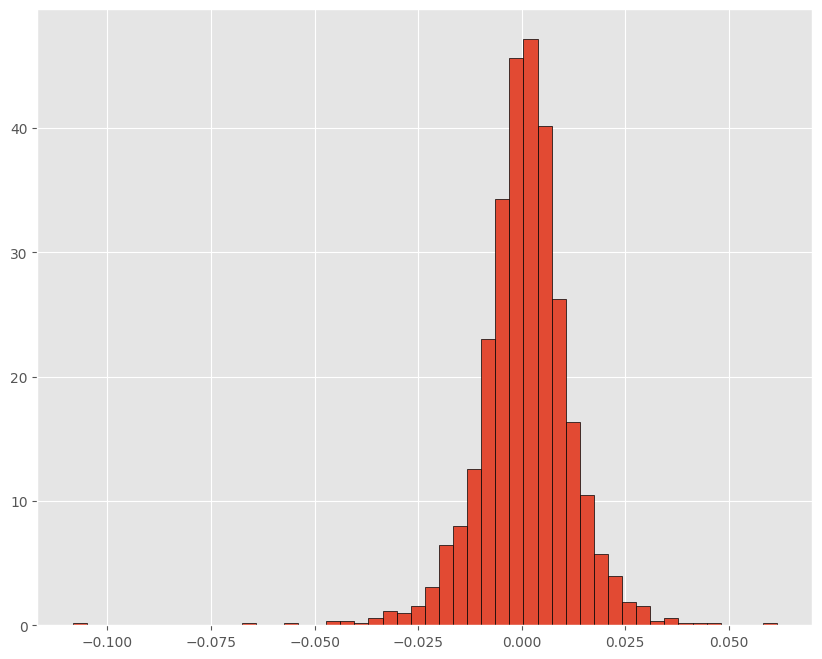

In [ ]:
gdr['Change'] = gdr['Close'] - gdr['Close'].shift()
gdr['LN_Change'] = np.log(gdr['Close'] / gdr['Close'].shift())
gdr.tail()

with plt.style.context('ggplot'):
    plt.figure(figsize=(10,8))
    plt.hist(gdr.LN_Change[1:], bins=50, edgecolor='Black', density='True')

gdr['Daily Vol'] = gdr['LN_Change'].rolling(21).std().shift()
